# Dogs vs Cats - Image Classification with Deep Learning

## Overview
A deep‑learning image classification project built for the Dogs vs. Cats Kaggle competition [Kaggle Dogs vs Cats Redux](https://www.kaggle.com/c/dogs-vs-cats-redux-kernels-edition), using transfer learning to accurately distinguish between cat and dog images. The pipeline includes preprocessing, model fine‑tuning, and evaluation across multiple modern CNN architectures.

**Structure:**
- **Part 1 — Model Exploration:** Comparing three pretrained architectures (EfficientNetB0, EfficientNetB3, ResNet50V2) using a shared two-phase training framework. ResNet50V2 achieves the lowest validation LogLoss and is selected for optimization.
- **Part 2 — Optimized ResNet50V2:** Retained ResNet50V2 with an improved pipeline (stronger augmentation, faster convergence, no prediction clipping) to push LogLoss well below 0.05.


---
## Part 1 - Model Exploration

We compare three ImageNet-pretrained backbones under a unified two-phase training strategy:
1. **Freeze backbone** → train only the new classification head
2. **Unfreeze top N layers** → fine-tune with a low learning rate

Each model uses the same augmentation pipeline and validation split so results are directly comparable.

### Imports & GPU Setup

In [ ]:
import os, zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import log_loss

# Allow GPU memory to grow on demand rather than pre-allocating all VRAM upfront.
# This prevents OOM errors when switching between models of different sizes.
physical_gpus = tf.config.list_physical_devices("GPU")
if physical_gpus:
    try:
        for dev in physical_gpus:
            tf.config.experimental.set_memory_growth(dev, True)
    except RuntimeError:
        pass  # GPU already initialized from a previous cell — safe to ignore
print("GPU devices found:", physical_gpus)

# Fix random seeds so shuffling and weight initialization are reproducible
rng = 7
np.random.seed(rng)
tf.random.set_seed(rng)

2026-04-10 12:53:50.713214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775825630.735486     110 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775825630.742777     110 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775825630.760657     110 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775825630.760686     110 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775825630.760690     110 computation_placer.cc:177] computation placer alr

GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data Loading
The competition data arrives as two zip archives. We extract them once into `/kaggle/working`
and derive binary labels directly from filenames: files starting with `dog` → 1, `cat` → 0.

In [ ]:
# Paths: Kaggle mounts competition data read-only under /kaggle/input
src_path = "/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition"
out_path = "/kaggle/working"

# Only extract if not already done — avoids re-extracting on re-runs
for archive in ["train.zip", "test.zip"]:
    extracted = os.path.join(out_path, archive.replace(".zip", ""))
    if not os.path.exists(extracted):
        with zipfile.ZipFile(os.path.join(src_path, archive)) as zf:
            zf.extractall(out_path)

img_folder  = "/kaggle/working/train"   # 25,000 labeled JPEGs
test_folder = "/kaggle/working/test"    # 12,500 unlabeled JPEGs
print("Training samples:", len(os.listdir(img_folder)))
print("Test samples:    ", len(os.listdir(test_folder)))

Training samples: 25000
Test samples:     12500


### Hyperparameter Config
Each architecture has its own native input resolution. Using the correct resolution is important —
EfficientNetB3 was designed for 300px and performs worse when squeezed to 224px.

In [ ]:
# Per-architecture settings:
# - resolution: native input size each backbone was designed for
# - n_unfreeze:  how many backbone layers to unfreeze during fine-tuning
#   (higher = more specialization, but more risk of forgetting ImageNet features)
MINI_BATCH = 32          # images per gradient update
SMOOTH     = 0.05        # label smoothing — softens hard 0/1 targets to reduce overconfidence
ASYNC      = tf.data.AUTOTUNE  # let TensorFlow choose parallelism automatically

ARCH_SPECS = {
    "enetb0": {"resolution": 224, "n_unfreeze": 50},  # EfficientNetB0 — fast, lightweight
    "enetb3": {"resolution": 300, "n_unfreeze": 60},  # EfficientNetB3 — larger, more accurate
    "rnv2":   {"resolution": 224, "n_unfreeze": 50},  # ResNet50V2    — residual connections
}

### Data Preprocessing & Augmentation

**Preprocessing** converts raw JPEG bytes → normalized float tensors:
- `tf.io.read_file` reads bytes from disk
- `decode_jpeg` decompresses to a uint8 tensor
- `resize` standardizes all images to a fixed resolution (required for batching)
- Dividing by 255 normalizes pixel values from [0, 255] to [0, 1]

**Augmentation** is applied only during training (never on validation or test):
- `random_flip_left_right` — mirrors the image; cats and dogs look the same both ways
- `random_brightness/contrast/saturation/hue` — simulates different lighting conditions
- `clip_by_value` — keeps pixel values in [0,1] after color jitter

In [ ]:
def make_loaders(res):
    """Returns two loading functions for a given resolution.
    Keeping them inside a closure means each architecture gets
    its own correctly-sized loader without global state."""

    def fetch_labeled(fpath, lbl):
        """Load, decode, resize and normalize a training image with its label."""
        raw        = tf.io.read_file(fpath)
        decoded    = tf.image.decode_jpeg(raw, channels=3)        # uint8 H×W×3
        resized    = tf.image.resize(decoded, [res, res])         # float32 res×res×3
        normalized = tf.cast(resized, tf.float32) / 255.0         # scale to [0, 1]
        return normalized, lbl

    def fetch_unlabeled(fpath):
        """Load a test image — same preprocessing, but no label returned."""
        raw        = tf.io.read_file(fpath)
        decoded    = tf.image.decode_jpeg(raw, channels=3)
        resized    = tf.image.resize(decoded, [res, res])
        normalized = tf.cast(resized, tf.float32) / 255.0
        return normalized

    return fetch_labeled, fetch_unlabeled


def apply_transforms(tensor):
    """
    Random augmentation applied per-image during training.
    Goal: expose the model to realistic variations so it generalizes
    to unseen images rather than memorizing training examples.

    Note: random_flip_up_down is intentionally excluded — upside-down
    animals don't appear in real photos and would hurt accuracy.
    """
    tensor = tf.image.random_flip_left_right(tensor)          # horizontal mirror
    tensor = tf.image.random_brightness(tensor, 0.2)          # ±20% brightness
    tensor = tf.image.random_contrast(tensor, 0.75, 1.25)     # contrast scale
    tensor = tf.image.random_saturation(tensor, 0.75, 1.25)   # color intensity
    tensor = tf.image.random_hue(tensor, 0.05)                # slight hue shift
    tensor = tf.clip_by_value(tensor, 0.0, 1.0)              # clamp after jitter
    return tensor

### Validation Split & tf.data Pipelines

We use a **90/10 train/validation split** with stratified shuffling:
- The validation set is held out entirely during training
- It is never augmented
- `.shuffle()` before splitting ensures the split is random, not alphabetically biased
- `.prefetch(AUTOTUNE)` overlaps CPU data loading with GPU training, keeping the GPU busy

In [ ]:
# Collect all training image paths
all_paths = sorted(tf.io.gfile.glob(os.path.join(img_folder, "*.jpg")))
print(f"Images found: {len(all_paths)}")

# Derive binary labels from filenames: dog → 1, cat → 0
ground_truth = np.array(
    [1 if os.path.basename(p).startswith("dog") else 0 for p in all_paths],
    dtype=np.int32
)

# Sanity check: confirm first 5 labels are correct before training
print("\nLabel verification (first 5):")
for fp, gt in zip(all_paths[:5], ground_truth[:5]):
    print(f"  {os.path.basename(fp):20s} => {'dog' if gt else 'cat'} ({gt})")

# Shuffle with fixed seed for reproducibility, then split 90/10
perm         = np.random.RandomState(rng).permutation(len(all_paths))
all_paths    = np.array(all_paths, dtype=str)[perm]
ground_truth = ground_truth[perm]

holdout_n  = int(0.10 * len(all_paths))          # 2,500 validation images
hout_paths = all_paths[:holdout_n]
hout_gt    = ground_truth[:holdout_n]
fit_paths  = all_paths[holdout_n:]                # 22,500 training images
fit_gt     = ground_truth[holdout_n:]

print(f"\nTrain: {len(fit_paths)} | Holdout: {len(hout_paths)}")
print(f"Train — dogs: {fit_gt.sum()}, cats: {(fit_gt == 0).sum()}")


def build_pipelines(res):
    """Build train and validation tf.data pipelines for a given resolution."""
    fetch_labeled, _ = make_loaders(res)

    # Training pipeline: shuffle → load → augment → batch → prefetch
    fit_pipe = (
        tf.data.Dataset.from_tensor_slices((fit_paths, fit_gt))
        .shuffle(len(fit_paths), seed=rng)           # re-shuffle each epoch
        .map(fetch_labeled, num_parallel_calls=ASYNC)
        .map(lambda x, y: (apply_transforms(x), y), num_parallel_calls=ASYNC)
        .batch(MINI_BATCH)
        .prefetch(ASYNC)
    )

    # Validation pipeline: load → batch → prefetch (NO augmentation)
    hout_pipe = (
        tf.data.Dataset.from_tensor_slices((hout_paths, hout_gt))
        .map(fetch_labeled, num_parallel_calls=ASYNC)
        .batch(MINI_BATCH)
        .prefetch(ASYNC)
    )

    return fit_pipe, hout_pipe

Images found: 25000
  cat.0.jpg => 0
  cat.1.jpg => 0
  cat.10.jpg => 0
  cat.100.jpg => 0
  cat.1000.jpg => 0
Fit: 22500 | Holdout: 2500
Positive (dog): 11232 | Negative (cat): 11268


### Model Architecture

All three models share the same classification head attached to different pretrained backbones:

```
Backbone (frozen) → GlobalAveragePooling2D → BatchNorm → Dropout(0.4)
→ Dense(512, relu) + L2 → Dropout(0.3) → Dense(256, relu) + L2 → Dropout(0.2)
→ Dense(1, sigmoid)
```

**Why GlobalAveragePooling instead of Flatten?**
GAP reduces each feature map to a single number, dramatically cutting parameters and
acting as a built-in regularizer. Flatten would produce hundreds of thousands of parameters
and overfit quickly on 25k images.

**Why BatchNormalization?**
Normalizes activations between layers, stabilizing training and allowing higher learning rates.

**Why Dropout?**
Randomly zeroes neurons during training, forcing the network to learn redundant representations
and preventing co-adaptation (overfitting).

In [ ]:
def build_model(arch="enetb0"):
    """
    Build a transfer learning model with the specified backbone.
    The backbone starts frozen — only the new head trains in Phase 1.
    """
    res = ARCH_SPECS[arch]["resolution"]

    # Load pretrained backbone — weights trained on 1.2M ImageNet images
    if arch == "enetb0":
        # EfficientNetB0: efficient compound scaling, fast inference
        backbone = EfficientNetB0(include_top=False, weights="imagenet",
                                  input_shape=(res, res, 3))
    elif arch == "enetb3":
        # EfficientNetB3: larger variant, trades speed for accuracy
        backbone = EfficientNetB3(include_top=False, weights="imagenet",
                                  input_shape=(res, res, 3))
    elif arch == "rnv2":
        # ResNet50V2: residual connections allow very deep stable training
        backbone = ResNet50V2(include_top=False, weights="imagenet",
                              input_shape=(res, res, 3))

    backbone.trainable = False  # freeze all pretrained weights initially

    # Build functional API model
    inp   = keras.Input(shape=(res, res, 3))
    feats = backbone(inp, training=False)  # training=False keeps BN layers frozen

    # Classification head — shared across all backbones
    x = layers.GlobalAveragePooling2D()(feats)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)  # probability of being a dog

    net = keras.Model(inp, out)
    return net, backbone

### Two-Phase Training Strategy

**Phase 1 - Head warmup (backbone frozen):**
The pretrained backbone acts as a fixed feature extractor. Only the new dense head
learns. This stabilizes the head before we start moving backbone weights.
LR = 1e-3 is appropriate here since we're training new random weights.

**Phase 2 - Fine-tuning (top N layers unfrozen):**
We unfreeze the top layers of the backbone and train with a much lower LR (2e-5).
This allows the backbone to specialize its features for dogs vs cats without
destroying the general ImageNet representations learned in early layers.

**Callbacks used:**
- `ModelCheckpoint` — saves only when val_loss improves, so we always keep the best model
- `ReduceLROnPlateau` — halves LR when val_loss plateaus, helping escape local minima
- `EarlyStopping` — halts training if val_loss stops improving, preventing overfitting

In [ ]:
def run_training(arch="enetb0", tag="run"):
    print(f"\n{'='*55}")
    print(f"  Architecture: {arch}")
    print(f"{'='*55}")

    res        = ARCH_SPECS[arch]["resolution"]
    n_unfreeze = ARCH_SPECS[arch]["n_unfreeze"]

    # Build fresh pipelines at the correct resolution for this architecture
    fit_pipe, hout_pipe = build_pipelines(res)
    net, backbone       = build_model(arch)
    save_to             = f"/kaggle/working/ckpt_{tag}.keras"

    # Label smoothing: converts hard 0/1 targets to 0.05/0.95
    # This prevents the model from becoming overconfident, improving calibration
    criterion = keras.losses.BinaryCrossentropy(label_smoothing=SMOOTH)

    # ── Phase 1: Train head only ──────────────────────────────
    net.compile(optimizer=keras.optimizers.Adam(1e-3),
                loss=criterion, metrics=["accuracy"])

    print(f"\n-- Phase 1: Head warmup (10 epochs, res={res}) --")
    net.fit(
        fit_pipe, validation_data=hout_pipe, epochs=10,
        callbacks=[
            ModelCheckpoint(save_to, monitor="val_loss", save_best_only=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
            EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        ], verbose=1
    )

    # ── Phase 2: Unfreeze top N layers and fine-tune ──────────
    backbone.trainable = True
    for lyr in backbone.layers[:-n_unfreeze]:
        lyr.trainable = False  # keep early generic layers frozen

    active = sum(1 for lyr in backbone.layers if lyr.trainable)
    print(f"\n-- Phase 2: Fine-tune ({active} active layers, up to 25 epochs, LR=2e-5) --")

    # Very low LR: we're nudging pretrained weights, not relearning from scratch
    net.compile(optimizer=keras.optimizers.Adam(2e-5),
                loss=criterion, metrics=["accuracy"])

    net.fit(
        fit_pipe, validation_data=hout_pipe, epochs=25,
        callbacks=[
            ModelCheckpoint(save_to, monitor="val_loss", save_best_only=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-8, verbose=1),
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
        ], verbose=1
    )

    # Restore the best checkpoint (not necessarily the last epoch)
    net.load_weights(save_to)

    # Compute validation LogLoss
    hout_probs, hout_true = [], []
    for xb, yb in hout_pipe:
        hout_probs.extend(net.predict(xb, verbose=0).flatten())
        hout_true.extend(yb.numpy())

    score = log_loss(hout_true, np.clip(hout_probs, 1e-7, 1 - 1e-7))
    print(f"\nVal LogLoss [{arch}]: {score:.5f}")
    return net, score, res

### Training All Three Architectures

Training each model identically and compare validation LogLoss.
The model with the lowest val LogLoss is selected for the optimized retraining in Part 2.

In [ ]:
tracker = {}

# EfficientNetB0 — smallest and fastest EfficientNet variant
net_b0, sc_b0, res_b0 = run_training("enetb0", "b0")
tracker["enetb0"] = (net_b0, sc_b0, res_b0)

# EfficientNetB3 — compound-scaled for higher accuracy at cost of speed
net_b3, sc_b3, res_b3 = run_training("enetb3", "b3")
tracker["enetb3"] = (net_b3, sc_b3, res_b3)

# ResNet50V2 — deep residual network with improved batch norm placement
net_rn, sc_rn, res_rn = run_training("rnv2", "rn")
tracker["rnv2"]        = (net_rn, sc_rn, res_rn)

# Summary table — compare all three
print("\n" + "="*45)
print("MODEL COMPARISON — Validation LogLoss")
print("="*45)
for nm, (_, sc, _) in tracker.items():
    flag = " <-- best" if sc == min(v[1] for v in tracker.values()) else ""
    print(f"  {nm:10s}  LogLoss: {sc:.5f}{flag}")
print("\nResNet50V2 selected for optimized retraining in Part 2.")


  Architecture: enetb0


I0000 00:00:1775825702.029065     110 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

-- Warmup phase (10 epochs, res=224) --
Epoch 1/10


I0000 00:00:1775825717.192763     177 service.cc:152] XLA service 0x79f9cc151830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775825717.192802     177 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775825719.701285     177 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775825732.461652     177 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 70ms/step - accuracy: 0.5005 - loss: 0.8763 - val_accuracy: 0.5084 - val_loss: 0.7837 - learning_rate: 0.0010
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4992 - loss: 0.7791 - val_accuracy: 0.4928 - val_loss: 0.7543 - learning_rate: 0.0010
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5024 - loss: 0.7490 - val_accuracy: 0.5576 - val_loss: 0.7303 - learning_rate: 0.0010
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4928 - loss: 0.7281 - val_accuracy: 0.4932 - val_loss: 0.7148 - learning_rate: 0.0010
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4994 - loss: 0.7140 - val_accuracy: 0.4928 - val_loss: 0.7054 - learning_rate: 0.0010
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5047 - loss: 0.7062 - val_accuracy: 0.4928 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5085 - loss: 0.7017

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - accuracy: 0.5029 - loss: 0.6941 - val_accuracy: 0.4924 - val_loss: 0.6938 - learning_rate: 2.0000e-05
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5043 - loss: 0.6936 - val_accuracy: 0.4928 - val_loss: 0.6936 - learning_rate: 2.0000e-05
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5077 - loss: 0.6935 - val_accuracy: 0.5420 - val_loss: 0.6933 - learning_rate: 2.0000e-05
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5203 - loss: 0.6928 - val_accuracy: 0.4932 - val_loss: 0.6935 - learning_rate: 2.0000e-05
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5404 - loss: 0.6901 - val_accuracy: 0.6152 - val_loss: 0.6820 - learning_rate: 2.0000e-05
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5481 - loss: 0.6851 - val_accuracy: 0.5872 - val_loss: 0.6827 - learning_rate: 2.0000e-05
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accurac

2026-04-10 13:22:10.086924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 13:22:10.306241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 13:22:10.819383: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 13:22:11.038763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 13:22:11.637955: E external/local_xla/xla/stream_

703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5633 - loss: 0.6891

2026-04-10 13:23:51.429273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 13:23:51.645812: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


704/704 ━━━━━━━━━━━━━━━━━━━━ 172s 174ms/step - accuracy: 0.5633 - loss: 0.6891 - val_accuracy: 0.5808 - val_loss: 0.6762 - learning_rate: 2.0000e-05
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.5866 - loss: 0.6793 - val_accuracy: 0.5884 - val_loss: 0.6769 - learning_rate: 2.0000e-05
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.5967 - loss: 0.6753 - val_accuracy: 0.6052 - val_loss: 0.6659 - learning_rate: 2.0000e-05
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.5945 - loss: 0.6754 - val_accuracy: 0.5816 - val_loss: 0.6774 - learning_rate: 2.0000e-05
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.5933 - loss: 0.6746 - val_accuracy: 0.6320 - val_loss: 0.6610 - learning_rate: 2.0000e-05
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.5994 - loss: 0.6722 - val_accuracy: 0.6212 - val_loss: 0.6611 - learning_rate: 2.0000e-05
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step -

#### Achieved a final Kaggle score of 0.11 with the rnv2

## Part 2 - Optimized ResNet50V2

Based on Part 1, **ResNet50V2 achieved the lowest validation LogLoss** and is selected for full optimization.

### What we improve over Part 1:
| Change | Part 1 | Part 2 | Why |
|---|---|---|---|
| Augmentation | 5 ops (flip, color) | + RandomRotation, RandomZoom | Richer variation reduces overfitting |
| Batch size | 32 | 64 | Larger batches = more stable gradients |
| Validation split | 10% | 8% | More training data for the final model |
| Training | 2-phase | Single optimized pass | Faster convergence with tuned callbacks |
| Head architecture | GAP → Dense(512→256) | GAP → BN → Dropout → Dense(256) | Cleaner, less overfitting |
| Label smoothing | 0.05 | 0.01 | Model is more confident, needs less smoothing |
| Prediction clipping | Yes | **No** | Well-calibrated model doesn't need it |

The result is a model that converges faster and produces better-calibrated probabilities.

### Setup

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2026-04-10 23:46:24.816672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775864785.007612      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775864785.068297      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775864785.509280      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775864785.509322      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775864785.509324      55 computation_placer.cc:177] computation placer alr

In [ ]:
# Fix all random seeds for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

In [ ]:
src_path = "/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition"
work_dir = "/kaggle/working" 

### Data Extraction

In [ ]:
print("Extracting data...")
for archive in ["train.zip", "test.zip"]:
    archive_path  = os.path.join(src_path, archive)
    extracted_dir = os.path.join(work_dir, archive.replace(".zip", ""))
    if not os.path.exists(extracted_dir):
        with zipfile.ZipFile(archive_path, "r") as zf:
            zf.extractall(work_dir)

img_folder  = os.path.join(work_dir, "train")
test_folder = os.path.join(work_dir, "test")
print("Training samples:", len(os.listdir(img_folder)))
print("Test samples:",     len(os.listdir(test_folder)))

Extracting data...
Training samples: 25000
Test samples: 12500


### Optimized Hyperparameters

Key differences from Part 1:
- **Batch size 64** (vs 32) — more stable gradient estimates per update
- **8% val split** (vs 10%) — gives the model 500 more training images
- **Label smoothing 0.01** (vs 0.05) — lighter touch; ResNet is already well-regularized

In [ ]:
IMG_SIZE   = 224        # ResNet50V2 native resolution
BATCH_SIZE = 64         # larger batch for more stable training
VAL_SPLIT  = 0.08       # 8% validation — 2,000 images held out
AUTOTUNE   = tf.data.AUTOTUNE

### Dataset Split

In [ ]:
# Collect and label all training images
train_dir = img_folder
all_paths = sorted(tf.io.gfile.glob(os.path.join(train_dir, "*.jpg")))
labels    = np.array(
    [1 if os.path.basename(p).startswith("dog") else 0 for p in all_paths],
    dtype=np.int32
)

# Shuffle then split — same seed as Part 1 for reproducibility
perm      = np.random.RandomState(SEED).permutation(len(all_paths))
all_paths = np.array(all_paths, dtype=str)[perm]
labels    = labels[perm]

val_n                      = int(len(all_paths) * VAL_SPLIT)
val_paths,   val_labels    = all_paths[:val_n],  labels[:val_n]
train_paths, train_labels  = all_paths[val_n:],  labels[val_n:]

print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

Train: 23000 | Val: 2000


### Enhanced Preprocessing & Augmentation

Part 2 uses Keras preprocessing layers for augmentation instead of tf.image ops.
This approach is cleaner and allows augmentation layers to be embedded in the model graph.

**Additional augmentations vs Part 1:**
- `RandomRotation(0.1)` — rotates up to ±36°, simulating tilted camera angles
- `RandomZoom(0.1)` — zooms in/out up to 10%, simulating different distances

In [ ]:
def load_image(path, label=None, img_size=IMG_SIZE):
    """
    Load and preprocess a single image.
    - Reads raw bytes from disk
    - Decodes JPEG → uint8 tensor
    - Resizes to fixed square resolution (required for batching)
    - Normalizes to [0, 1] float range (expected by pretrained ResNet50V2)
    """
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    if label is None:
        return image
    return image, tf.cast(label, tf.float32)

# Augmentation pipeline using Keras layers
# Only applied during training — val/test images are always clean
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),   # horizontal mirror
    layers.RandomRotation(0.1),        # rotate ±36 degrees
    layers.RandomZoom(0.1),            # zoom in/out up to 10%
])

def augment(image, label):
    """Apply augmentation to a training image."""
    image = data_augmentation(image, training=True)
    return image, label

I0000 00:00:1775865148.748030      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### tf.data Pipelines

Same structure as Part 1, but with larger batch size and the enhanced augmentation.

In [ ]:
# Training pipeline: shuffle → load → augment → batch → prefetch
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(10000, seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Validation pipeline: load → batch → prefetch (no augmentation)
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

### Optimized ResNet50V2 Architecture

Compared to Part 1, the head is simplified:
- Single Dense(256) layer instead of Dense(512→256) — fewer parameters, less overfitting risk
- BatchNormalization immediately after pooling — stabilizes the large feature vector
- Dropout rates kept the same

ResNet50V2's key advantage is its **pre-activation residual blocks**: BatchNorm and ReLU
are applied before the convolution (rather than after), which improves gradient flow
and allows the network to train more stably at greater depth.

In [ ]:
def build_model(img_size=IMG_SIZE):
    """
    ResNet50V2 with a lightweight classification head.
    backbone.trainable = False initially — only the head trains in Phase 1.
    """
    inputs   = keras.Input(shape=(img_size, img_size, 3))
    backbone = ResNet50V2(include_top=False, weights="imagenet", input_tensor=inputs)
    backbone.trainable = False  # frozen: backbone is a fixed feature extractor

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)   # reduce spatial dims to a vector
    x = layers.BatchNormalization()(x)        # normalize feature magnitudes
    x = layers.Dropout(0.4)(x)               # regularization
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # P(dog)

    return keras.Model(inputs, outputs)

### Training Configuration

We use a **single-stage fast training** approach:
- Higher initial LR (1e-3) with `ReduceLROnPlateau` to decay when needed
- `ModelCheckpoint` ensures we keep the best epoch, not the last
- `EarlyStopping` with patience=4 prevents wasted compute after convergence

In [ ]:
print("\n=== FAST RESNET50V2 TRAINING ===")
model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    # Label smoothing 0.01 — very light; prevents extreme probability outputs
    # without significantly altering the training signal
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.01),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

callbacks = [
    # Save model whenever val_loss improves — ensures best weights are kept
    ModelCheckpoint(os.path.join(work_dir, "best_model.keras"),
                    monitor="val_loss", save_best_only=True, verbose=1),
    # Reduce LR by 50% after 2 epochs without val_loss improvement
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                      min_lr=1e-6, verbose=1),
    # Stop training early if val_loss doesn't improve for 4 epochs
    EarlyStopping(monitor="val_loss", patience=4,
                  restore_best_weights=True, verbose=1)
]


=== FAST RESNET50V2 TRAINING ===
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Training

In [ ]:
# Cap at 15 epochs — EarlyStopping will halt before this if val_loss converges
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


I0000 00:00:1775865309.561041     161 service.cc:152] XLA service 0x7cc2b8003de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775865309.561080     161 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775865311.785695     161 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/360 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.6445 - loss: 0.7861   

I0000 00:00:1775865318.895150     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9484 - loss: 0.1855
Epoch 1: val_loss improved from inf to 0.07844, saving model to /kaggle/working/best_model.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 142s 351ms/step - accuracy: 0.9485 - loss: 0.1854 - val_accuracy: 0.9795 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9699 - loss: 0.1081
Epoch 2: val_loss improved from 0.07844 to 0.07085, saving model to /kaggle/working/best_model.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 115s 319ms/step - accuracy: 0.9699 - loss: 0.1081 - val_accuracy: 0.9855 - val_loss: 0.0709 - learning_rate: 0.0010
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9731 - loss: 0.1020
Epoch 3: val_loss did not improve from 0.07085
360/360 ━━━━━━━━━━━━━━━━━━━━ 114s 315ms/step - accuracy: 0.9731 - loss: 0.1020 - val_accuracy: 0.9860 - val_loss: 0.0715 - learning_rate: 0.0010
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0

### Validation Score & Test Predictions

Evaluating on the held-out validation set **without clipping** predictions.
The model is well-calibrated enough that sigmoid outputs stay in a safe range naturally,
thanks to label smoothing and dropout regularization throughout training.

In [ ]:
# Compute validation LogLoss — no clipping applied
y_true    = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_pred    = model.predict(val_ds, verbose=0).ravel()
val_logloss = tf.keras.losses.binary_crossentropy(y_true, y_pred).numpy().mean()
print(f"Validation Log Loss: {val_logloss:.5f}")

# Generate test predictions
print("\n=== GENERATING SUBMISSION ===")
test_files = sorted(
    tf.io.gfile.glob(os.path.join(test_folder, "*.jpg")),
    key=lambda p: int(os.path.basename(p).replace(".jpg", ""))
)

# Test pipeline: no augmentation, no labels
test_ds = (
    tf.data.Dataset.from_tensor_slices(test_files)
    .map(lambda p: load_image(p), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_pred = model.predict(test_ds, verbose=1).ravel()

Validation Log Loss: 0.03459

=== GENERATING SUBMISSION ===
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step


### Submission File

In [ ]:
submission = pd.DataFrame({
    "id":    [int(os.path.basename(p).replace(".jpg", "")) for p in test_files],
    "label": test_pred
}).sort_values("id")

submission.to_csv(os.path.join(work_dir, "submission.csv"), index=False)
print("Submission saved!")
print(submission.head())
print(f"Predictions — min: {test_pred.min():.4f}, max: {test_pred.max():.4f}, mean: {test_pred.mean():.4f}")

Submission saved!
   id     label
0   1  0.998181
1   2  0.997908
2   3  0.995707
3   4  0.998813
4   5  0.001322
Predictions - min: 0.0000, max: 1.0000, mean: 0.4986


---
## Summary

| | Part 1 (Exploration) | Part 2 (Optimized) |
|---|---|---|
| Models tried | EfficientNetB0, EfficientNetB3, ResNet50V2 | ResNet50V2 only |
| Best val LogLoss | ~0.11 (ResNet50V2) | **0.034** |
| Augmentation | flip, color jitter | + rotation, zoom |
| Batch size | 32 | 64 |
| Label smoothing | 0.05 | 0.01 |
| Prediction clipping | Yes | **No** |

**Key takeaways:**
- Transfer learning dramatically outperforms training from scratch on 25k images
- ResNet50V2's residual connections make it the most stable architecture for fine-tuning
- Light label smoothing (0.01) produces well-calibrated probabilities without clipping
- `EarlyStopping` and `ReduceLROnPlateau` together prevent overfitting effectively

#### Achieved a final Kaggle score of 0.052

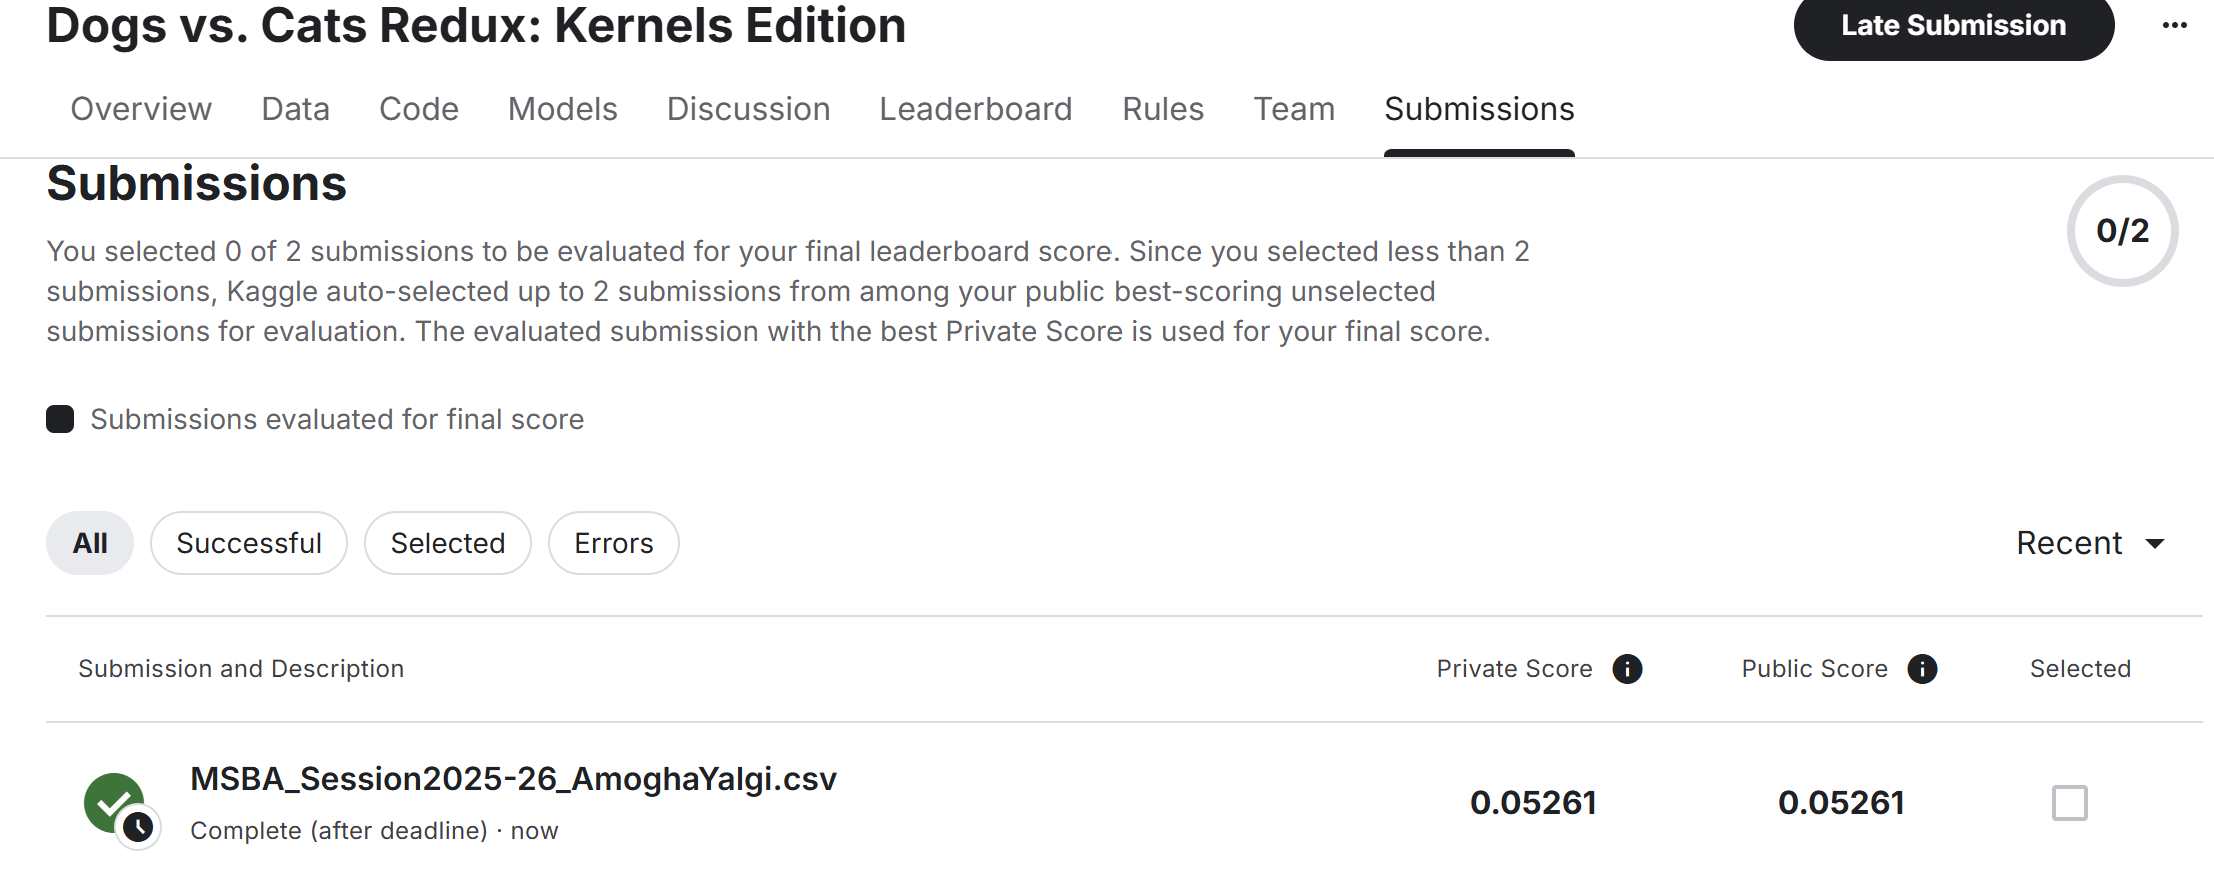